# Tumor Detection - ResNet

**Goal:** Detect tumors in brain MRIs with a ResNet classifier.


1. Pretrained ResNet-18 (transfer learning) - train + evaluate
2. Custom ResNet built from scratch
3. Compare the two


## 0. Environment setup

In [1]:
import sys, shutil, os

# Long's preprocess.py is shipped via the support Kaggle dataset; copy it into
# the writable working dir so we can `import preprocess`.
SUPPORT   = "/kaggle/input/datasets/ragtxt/brain-tumor-detection-support"
DATA_ROOT = "/kaggle/input/datasets/ragtxt/brain-tumor-roboflow-v1"
WORK      = "/kaggle/working"

for f in os.listdir(SUPPORT):
    shutil.copy(os.path.join(SUPPORT, f), WORK)
sys.path.insert(0, WORK)

os.makedirs(f"{WORK}/models", exist_ok=True)
os.makedirs(f"{WORK}/plots", exist_ok=True)
print("working dirs ready")

working dirs ready


In [2]:
import torch, matplotlib.pyplot as plt, random
import pandas as pd
import seaborn as sns
from PIL import Image
from preprocess import ImagePreprocessor

torch.manual_seed(36)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. Model Training - ResNet (PyTorch)

**Approach:** Transfer learning. ImageNet-pretrained ResNet-18 backbone, replace the `fc` head with a 2-class linear layer, and train only the head (the backbone stays frozen).

**Steps:**
- Build train/val/test loaders with Long's `ImagePreprocessor`.
- Define the model with a replaced head.
- Train with early stopping + best-val checkpoint.
- Plot the loss curve.

In [3]:
from torchvision.datasets import ImageFolder

preprocessor = ImagePreprocessor(size=(227, 227))
train_ds = ImageFolder(f"{DATA_ROOT}/train", transform=preprocessor.train_transform)
val_ds   = ImageFolder(f"{DATA_ROOT}/valid", transform=preprocessor.test_transform)
test_ds  = ImageFolder(f"{DATA_ROOT}/test",  transform=preprocessor.test_transform)

BATCH = 32
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

classes = train_ds.classes
print("classes:", classes, "| train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

classes: ['NoTumor', 'Tumor'] | train: 160 val: 45 test: 23


In [4]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)
for p in model.parameters():
    p.requires_grad = False

num_classes = len(classes)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable params:", trainable)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


trainable params: 1026


In [5]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

EPOCHS = 25
PATIENCE = 7
BEST = f"{WORK}/models/resnet18.pt"

best_val = float("inf")
no_improve = 0
train_losses, val_losses = [], []

In [6]:
for epoch in range(EPOCHS):
    model.train()
    tl = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        tl += loss.item()
    tl /= len(train_loader)
    train_losses.append(tl)

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            vl += criterion(model(x), y).item()
    vl /= len(val_loader)
    val_losses.append(vl)

    print(f"epoch {epoch+1:02d} | train {tl:.4f} | val {vl:.4f}")

    if vl < best_val:
        best_val = vl
        no_improve = 0
        torch.save(model.state_dict(), BEST)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"early stop @ epoch {epoch+1}")
            break

print("best val loss:", best_val)

epoch 01 | train 0.7029 | val 0.5458
epoch 02 | train 0.6430 | val 0.6312
epoch 03 | train 0.5630 | val 0.5211
epoch 04 | train 0.5286 | val 0.4957
epoch 05 | train 0.4860 | val 0.4664
epoch 06 | train 0.4690 | val 0.4332
epoch 07 | train 0.4482 | val 0.4362
epoch 08 | train 0.4262 | val 0.3805
epoch 09 | train 0.3972 | val 0.3716
epoch 10 | train 0.3922 | val 0.3741
epoch 11 | train 0.3870 | val 0.3749
epoch 12 | train 0.3833 | val 0.3121
epoch 13 | train 0.3598 | val 0.2994
epoch 14 | train 0.3543 | val 0.3337
epoch 15 | train 0.3548 | val 0.2742
epoch 16 | train 0.3415 | val 0.2640
epoch 17 | train 0.3192 | val 0.2661
epoch 18 | train 0.3355 | val 0.2665
epoch 19 | train 0.3328 | val 0.2570
epoch 20 | train 0.3395 | val 0.2398
epoch 21 | train 0.3192 | val 0.2436
epoch 22 | train 0.2870 | val 0.2362
epoch 23 | train 0.3048 | val 0.2246
epoch 24 | train 0.2927 | val 0.2255
epoch 25 | train 0.3263 | val 0.2235
best val loss: 0.22351676225662231


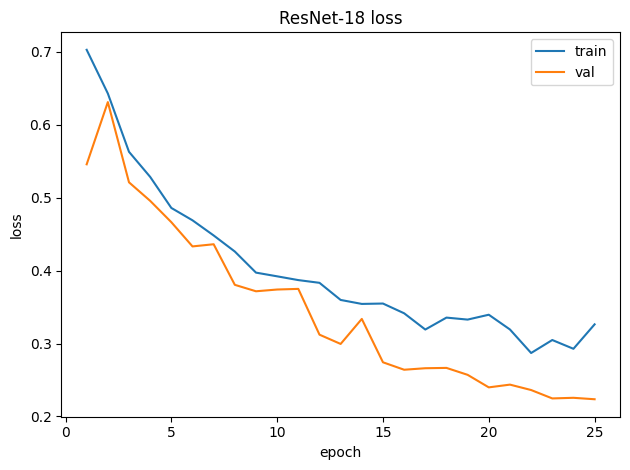

In [7]:
ep = range(1, len(train_losses) + 1)
sns.lineplot(x=ep, y=train_losses, label="train")
sns.lineplot(x=ep, y=val_losses,   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("ResNet-18 loss")
plt.tight_layout()
plt.savefig(f"{WORK}/plots/loss_curve_resnet18.png")
plt.show()

## 2. Visualization & Reporting

**Tasks:**
- Load best checkpoint, evaluate on test set.
- Print accuracy + classification report.
- Confusion matrix.
- Sample-prediction grid (correct + failures).

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# load the best checkpoint saved during training, evaluate on the test set
model.load_state_dict(torch.load(BEST, map_location=device))
model.eval()

all_pred, all_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_pred += model(x).argmax(1).cpu().tolist()
        all_true += y.tolist()

acc = sum(int(p == t) for p, t in zip(all_pred, all_true)) / len(all_true)
print(f"test accuracy: {acc:.4f}")
print(classification_report(all_true, all_pred, target_names=classes))

test accuracy: 0.8261
              precision    recall  f1-score   support

     NoTumor       1.00      0.56      0.71         9
       Tumor       0.78      1.00      0.88        14

    accuracy                           0.83        23
   macro avg       0.89      0.78      0.79        23
weighted avg       0.86      0.83      0.81        23



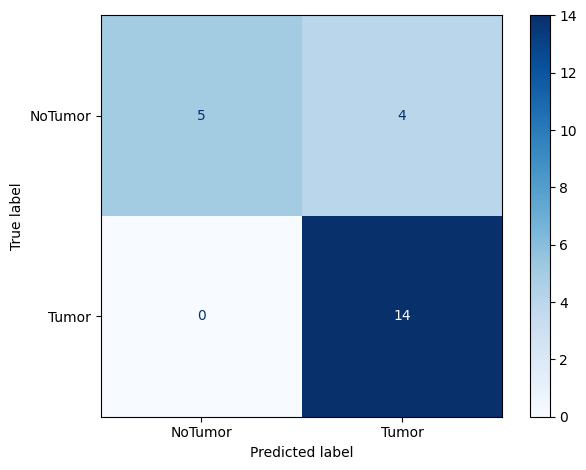

In [9]:
cm = confusion_matrix(all_true, all_pred)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(cmap="Blues")
plt.tight_layout()
plt.savefig(f"{WORK}/plots/confusion_resnet18.png")
plt.show()

selected 8 samples (4 misses available)


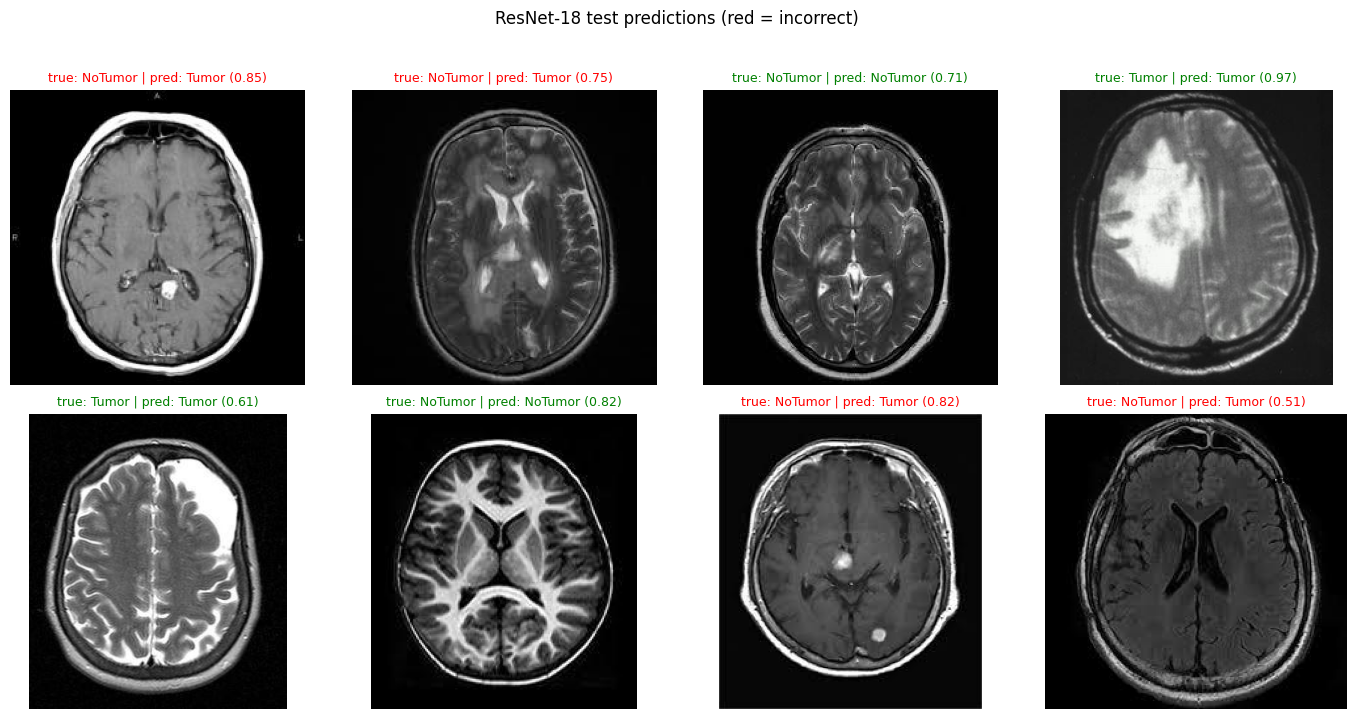

In [10]:
# Sample predictions grid - mix of correct and incorrect
import torch.nn.functional as F

paths, preds, trues, probs = [], [], [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        p = F.softmax(logits, dim=1).cpu()
        preds += logits.argmax(1).cpu().tolist()
        trues += y.tolist()
        probs += p.max(1).values.tolist()

paths = [s[0] for s in test_ds.samples]

correct_idx = [i for i in range(len(paths)) if preds[i] == trues[i]]
wrong_idx   = [i for i in range(len(paths)) if preds[i] != trues[i]]

random.seed(36)
picks  = random.sample(wrong_idx,   min(4, len(wrong_idx)))
picks += random.sample(correct_idx, 8 - len(picks))
random.shuffle(picks)
print(f'selected {len(picks)} samples ({len(wrong_idx)} misses available)')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.flat, picks):
    img = Image.open(paths[i]).convert('RGB')
    ax.imshow(img, cmap='gray')
    ok = preds[i] == trues[i]
    color = 'green' if ok else 'red'
    title = f'true: {classes[trues[i]]} | pred: {classes[preds[i]]} ({probs[i]:.2f})'
    ax.set_title(title, color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('ResNet-18 test predictions (red = incorrect)', y=1.02)
plt.tight_layout()
plt.savefig(f'{WORK}/plots/sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Custom ResNet from scratch (comparison)

So far we used an ImageNet-**pretrained** ResNet-18. Here we build a small ResNet
**from scratch** (random weights) and train it on the same data, so we can compare
what transfer learning buys us.

Key idea of ResNet = the **skip connection**: each block computes `out = relu(F(x) + x)`.
Adding the input `x` back lets gradients flow straight through, so deep networks
still train. Everything below uses the same loaders, loss, and metric as the
pretrained model for a fair, apples-to-apples comparison.

In [11]:
# Building blocks of a ResNet, written out by hand
import torch.nn as nn
import torch.nn.functional as F


class BasicBlock(nn.Module):
    # two 3x3 convs + a skip connection:  out = relu(F(x) + x)
    def __init__(self, c_in, c_out, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(c_out)
        # if the block changes size/channels, reshape the skip path to match
        if stride == 1 and c_in == c_out:
            self.shortcut = nn.Sequential()
        else:
            self.shortcut = nn.Sequential(
                nn.Conv2d(c_in, c_out, 1, stride, bias=False),
                nn.BatchNorm2d(c_out),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)   # <-- the residual / skip connection
        return F.relu(out)


class SmallResNet(nn.Module):
    # tiny ResNet: stem -> 3 residual blocks -> global average pool -> classifier
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = BasicBlock(16, 16, stride=1)
        self.layer2 = BasicBlock(16, 32, stride=2)
        self.layer3 = BasicBlock(32, 64, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


In [12]:
# Build the custom model. Note: ALL parameters train (no frozen backbone).
custom = SmallResNet(num_classes).to(device)
custom_opt = torch.optim.Adam(custom.parameters(), lr=1e-3)

custom_params = sum(p.numel() for p in custom.parameters() if p.requires_grad)
print("custom ResNet trainable params:", custom_params)


custom ResNet trainable params: 79442


In [13]:
# Train the custom ResNet (same recipe as the pretrained head: Adam + early stopping)
EPOCHS_C = 25
PATIENCE_C = 7
BEST_C = f"{WORK}/models/resnet_custom.pt"

best_val_c = float("inf")
no_improve_c = 0
train_losses_c, val_losses_c = [], []

for epoch in range(EPOCHS_C):
    custom.train()
    tl = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        custom_opt.zero_grad()
        loss = criterion(custom(x), y)
        loss.backward()
        custom_opt.step()
        tl += loss.item()
    tl /= len(train_loader)
    train_losses_c.append(tl)

    custom.eval()
    vl = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            vl += criterion(custom(x), y).item()
    vl /= len(val_loader)
    val_losses_c.append(vl)

    print(f"epoch {epoch+1:02d} | train {tl:.4f} | val {vl:.4f}")

    if vl < best_val_c:
        best_val_c = vl
        no_improve_c = 0
        torch.save(custom.state_dict(), BEST_C)
    else:
        no_improve_c += 1
        if no_improve_c >= PATIENCE_C:
            print(f"early stop @ epoch {epoch+1}")
            break

print("best custom val loss:", best_val_c)


epoch 01 | train 0.6687 | val 0.7808
epoch 02 | train 0.5926 | val 0.9505
epoch 03 | train 0.5429 | val 0.9018
epoch 04 | train 0.5187 | val 0.7223
epoch 05 | train 0.4944 | val 0.5268
epoch 06 | train 0.4981 | val 0.4563
epoch 07 | train 0.4568 | val 0.5095
epoch 08 | train 0.4666 | val 0.6279
epoch 09 | train 0.4629 | val 0.6169
epoch 10 | train 0.4573 | val 0.4641
epoch 11 | train 0.4511 | val 0.8589
epoch 12 | train 0.4202 | val 1.0062
epoch 13 | train 0.4285 | val 1.3519
early stop @ epoch 13
best custom val loss: 0.4562816023826599


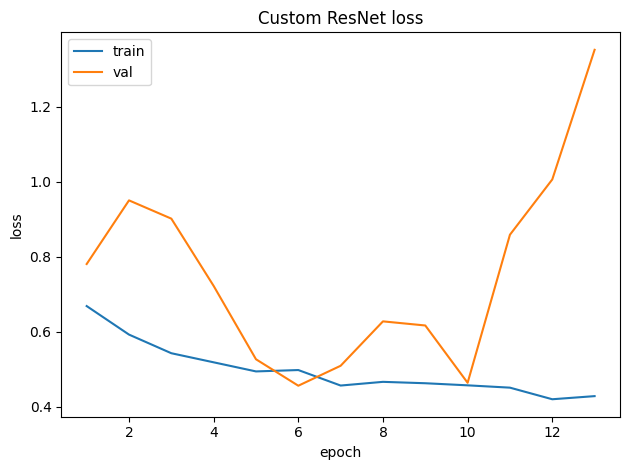

In [14]:
# Loss curve for the custom model
ep = range(1, len(train_losses_c) + 1)
sns.lineplot(x=ep, y=train_losses_c, label="train")
sns.lineplot(x=ep, y=val_losses_c,   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Custom ResNet loss")
plt.tight_layout()
plt.savefig(f"{WORK}/plots/loss_curve_custom.png")
plt.show()


In [15]:
# Side-by-side comparison: pretrained ResNet-18 vs custom from-scratch ResNet
custom.load_state_dict(torch.load(BEST_C, map_location=device))

def test_accuracy(m):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            pred = m(x).argmax(1).cpu()
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

acc_pretrained = test_accuracy(model)   # 'model' holds the best pretrained checkpoint
acc_custom     = test_accuracy(custom)
best_val_pretrained = best_val

table = pd.DataFrame([
    {"model": "ResNet-18 (pretrained)",
     "params": sum(p.numel() for p in model.parameters()),
     "best val loss": round(best_val_pretrained, 4),
     "test accuracy": round(acc_pretrained, 4)},
    {"model": "Custom ResNet (scratch)",
     "params": custom_params,
     "best val loss": round(best_val_c, 4),
     "test accuracy": round(acc_custom, 4)},
])
print(table.to_string(index=False))


                  model   params  best val loss  test accuracy
 ResNet-18 (pretrained) 11177538         0.2235         0.8261
Custom ResNet (scratch)    79442         0.4563         0.9565


## 4. Limitations & Future Work

<!-- _Fill in for the report / slides._

- Small dataset size and class imbalance.
- MRI artifacts (motion, intensity inhomogeneity) not modeled.
- Binary classification only - no tumor localization.
- Generalization to other scanners / hospitals unverified.
- Future: ResNet-50 / EfficientNet baseline, Grad-CAM for interpretability, segmentation with SAM or U-Net. -->